In [27]:
import torch 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from cdft.dft1d import dft_core
from cdft.lj_eos_thol import lj_eos

torch.set_default_dtype(torch.float64)
device = torch.device('cpu')

pi = np.pi
kB = 1.380649e-23
NA = 6.02214076e23

plt.rcParams.update({'text.usetex':True, 
'font.family':'sans-serif', 
'font.size':18, 
'axes.linewidth':1.1,
'text.latex.preamble': r'\usepackage{sfmath}'
})

colors = sns.color_palette("mako")

In [28]:
sigma = 3.615
epsilon = 101.5
parameters = {'sigma':sigma, 'epsilon':epsilon}

In [29]:
T = 77.4
eos = lj_eos(parameters, T)
P0 = eos.vapor_pressure(1e5)
P0 = float(P0[0].numpy())
P = torch.hstack((torch.logspace(-7,-1,10*6), torch.arange(0.11,1.0,0.01)))*P0

bulk_density = torch.empty_like(P)

bulk_density[0] = eos.density(P[0],'vap')
for i in range(1,len(P)):
    bulk_density[i] = eos.density(P[i],bulk_density[i-1])

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_30192/4246141807.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  nist = pd.read_csv('data/N2_77K_NIST.txt', sep='\s+', skiprows=1,


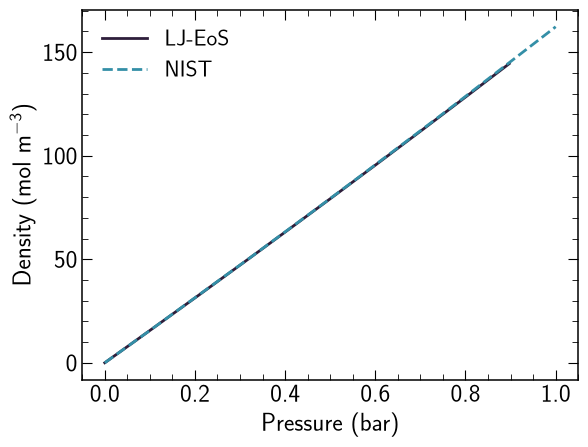

In [30]:
nist = pd.read_csv('data/N2_77K_NIST.txt', sep='\s+', skiprows=1, 
                    usecols=[1,2], names=['Pressure (bar)','Density (mol/m3)'])

colors = sns.color_palette("mako")

plt.plot(P*1e-5, bulk_density*1e30/(NA), '-', color=colors[0], linewidth=2.0, label='LJ-EoS')
plt.plot(nist['Pressure (bar)'],nist['Density (mol/m3)'], '--', color=colors[3], linewidth=2.0, label='NIST')
plt.xlabel(r'Pressure (bar)', fontsize=18)
plt.ylabel(r'Density (mol m$^{-3}$)', fontsize=18)
plt.minorticks_on()
plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=7, bottom=True, top=True, left=True, right=True)
# plt.xticks(xticks)
# plt.yticks(yticks)
plt.legend(fontsize=16, frameon=False, edgecolor='k')

In [31]:
H = 36.0
pad = 4.0
dz = 0.02

system_size = H+2.0*pad
points = int(round(system_size/dz))
cell_size = system_size/points
kin = int(round(pad/cell_size))
kout = points-kin

def steele(z,sigma,epsilon):
    rhos = 0.114
    Delta = 3.35
    return 2.0*pi*rhos*epsilon*sigma**2*Delta*(0.40*(sigma/z)**10-(sigma/z)**4-sigma**4/(3.0*Delta*(z+0.610*Delta)**3))

sigma_s = 3.40
epsilon_s = 28.0
sigma_is = 0.5*(sigma+sigma_s) 
epsilon_is = np.sqrt(epsilon*epsilon_s)

dft = dft_core(parameters, T, system_size, points, device)
Vext = torch.zeros_like(dft.z)
Vext[0:kin] = np.inf
Vext[kout:] = np.inf
zp = dft.z[kin:kout]-pad
Vext[kin:kout] = steele(zp,sigma_is,epsilon_is)+steele(H-zp,sigma_is,epsilon_is)

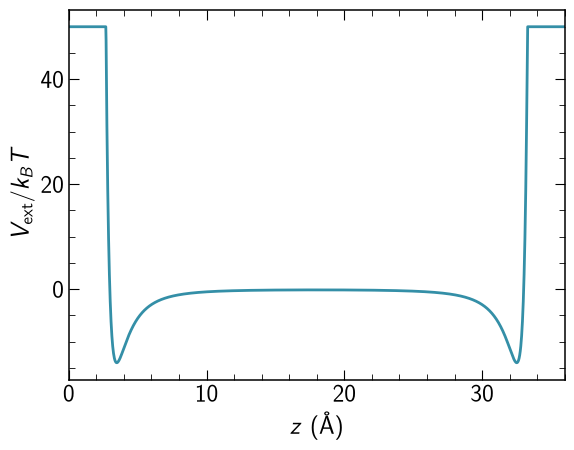

In [32]:
dft.initial_condition(bulk_density[0],Vext,potential_cutoff=50.)

plt.plot(dft.z.cpu()-pad,dft.Vext.cpu(),color=colors[3],linewidth=2.0)
plt.xlabel(r'$z$ (\AA{})', fontsize=18)
plt.ylabel(r'$V_{\mathrm{ext}}/k_BT$', fontsize=18)
plt.xlim(0.0,H)
plt.minorticks_on()
plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=7, bottom=True, top=True, left=True, right=True)

In [33]:
Nads = torch.empty_like(P)
Ndes = torch.empty_like(P) 
Omega_ads = torch.empty_like(P)
Omega_des = torch.empty_like(P)

for i in range(len(P)):
    dft.equilibrium_density_profile(bulk_density[i],fmt='WB',solver='fire',
                                    alpha0=0.2,dt=0.02,tol=1e-8,max_it=20000,logoutput=False)
    Nads[i] = dft.total_molecules 
    Omega_ads[i] = dft.Omega
    print(dft.it,dft.error.numpy(),P[i].numpy()/P0,Nads[i].numpy())  
    if np.isnan(dft.error.numpy()): break

173 6.398197083702275e-11 9.999999999999998e-08 8.313414682326185e-06
146 6.503628416046457e-10 1.2638482029342972e-07 1.0507776302983232e-05
146 6.629990202351988e-10 1.5973122800602558e-07 1.3281643545172278e-05
146 6.79264514067791e-10 2.018760254679039e-07 1.6788233264263888e-05
146 7.002660091513828e-10 2.5514065200312876e-07 2.122137704296345e-05
146 7.275372037413221e-10 3.224590545296398e-07 2.6826350469368797e-05
146 7.631157739719583e-10 4.0753929658717785e-07 3.391362768708738e-05
146 8.098197085777252e-10 5.150678076168122e-07 4.2876374095143705e-05
146 8.715360643585127e-10 6.509675230458164e-07 5.421272949105988e-05
146 9.535755698693456e-10 8.227241341700474e-07 6.855425189913399e-05
146 1.0632489833520202e-09 1.03979841848149e-06 8.670231915742569e-05
146 1.2105184195718849e-09 1.314147362611758e-06 0.00010967486566969375
146 1.4086072663302763e-09 1.6608827826277167e-06 0.00013876663246463404
146 1.67451225145833e-09 2.0991037201085544e-06 0.00017562723228666603
146 2.

In [34]:
Ndes[-1] = dft.total_molecules
Omega_des[-1] = dft.Omega
for i in range(len(P)-2,-1,-1):
    dft.equilibrium_density_profile(bulk_density[i],fmt='WB',solver='fire',
                                    alpha0=0.1,dt=0.01,tol=1e-8,max_it=20000,logoutput=False)
    Ndes[i] = dft.total_molecules 
    Omega_des[i] = dft.Omega
    print(dft.it,dft.error.numpy(),P[i].numpy()/P0,Ndes[i].numpy())   
    if np.isnan(dft.error.numpy()): break

251 9.53518523646739e-09 0.9800000000000001 0.5937157527082605
258 9.706686339013798e-09 0.9700000000000002 0.5934796841829214
252 9.545614322233653e-09 0.9600000000000001 0.5932404853633504
253 9.32593189507029e-09 0.9500000000000001 0.5929980762507185
253 9.921460650524444e-09 0.9400000000000002 0.5927523770340475
252 8.928771405933987e-09 0.93 0.5925033038635162
257 8.360131554140876e-09 0.92 0.5922507694209047
269 9.227398840018735e-09 0.9099999999999999 0.5919946845409794
262 9.606267481389087e-09 0.9 0.5917349550140273
267 9.673684136108316e-09 0.89 0.591471482549468
282 8.4958612099968e-09 0.8799999999999999 0.5912041674596454
276 9.789819362073144e-09 0.8700000000000001 0.5909329031333291
273 7.979214068995957e-09 0.8600000000000002 0.5906575800925147
275 9.40361543891216e-09 0.8500000000000001 0.590378084295022
290 9.92488332338386e-09 0.8400000000000001 0.5900942968530625
280 9.81625759177211e-09 0.8300000000000002 0.5898060935298814
251 9.595706229792062e-09 0.82000000000000

In [35]:
Neq = np.copy(Nads)
Omega_eq = np.copy(Omega_ads)
for i in range(len(P)):
    if Omega_des[i] < Omega_ads[i]:
        Omega_eq[i] = Omega_des[i]
        Neq[i] = Ndes[i]

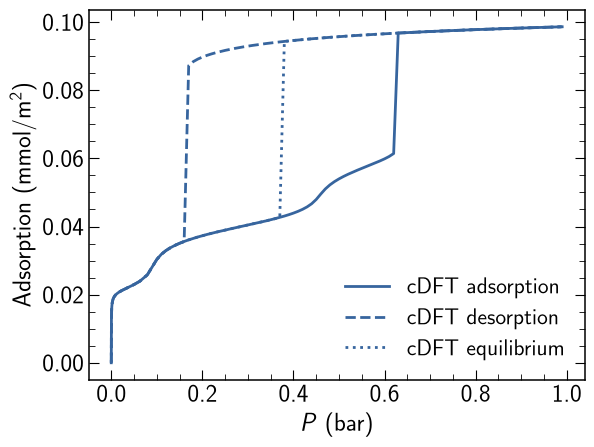

In [38]:
plt.plot(P/P0, (1e23/NA)*Nads, '-', color=colors[2], linewidth=2.0, label='cDFT adsorption')
plt.plot(P/P0, (1e23/NA)*Ndes, '--', color=colors[2], linewidth=2.0, label='cDFT desorption')
plt.plot(P/P0, (1e23/NA)*Neq, ':', color=colors[2], linewidth=2.0, label='cDFT equilibrium')
plt.xlabel(r'$P$ (bar)', fontsize=18)
plt.ylabel(r'Adsorption (mmol/m$^2$)', fontsize=18)
plt.minorticks_on()
# plt.xscale('log')
plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=7, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=False, edgecolor='k')

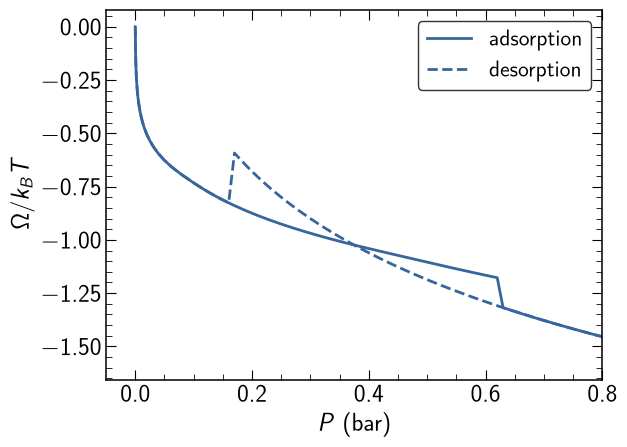

In [32]:
colors = sns.color_palette("mako")

plt.plot(P/P0, Omega_ads, '-', color=colors[2], linewidth=2.0, label='adsorption')
plt.plot(P/P0, Omega_des, '--', color=colors[2], linewidth=2.0, label='desorption')
plt.xlabel(r'$P$ (bar)', fontsize=18)
plt.ylabel(r'$\Omega/k_B T$', fontsize=18)
plt.xlim([None,0.8])
# plt.ylim([0.0,2000])
plt.minorticks_on()
plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=7, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=True, edgecolor='k')